# AGES+ Figure: CROCUS NEIU Boundary Layer Evolution

[CROCUS](https://crocus-urban.org/) utilizes the Vasiala CL-61 within the Chicago Micronet Level 3 nodes. <br>
Data are collected at the instrument via the Waggle node. <br>

During AGES+, a Doppler Lidar was added to the Northeastern Illinois site. 

This notebook generates a timeseries from both instruments and corrects time to local time.

In [1]:
import glob

import numpy as np
import xarray as xr
import pandas as pd
from xarray.backends import NetCDF4DataStore
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from zoneinfo import ZoneInfo

import act
import cmweather

## Define the DL files - across 1 Aug and 2 Aug

In [2]:
DATE = "20230802"

In [3]:
file_list = sorted(glob.glob("/nfs/gce/projects/crocus/data/ingested-data/field-campaigns/ages-plus-2023/neiu-doppler-lidar-a1/netcdf/" + "20230802" + "/*"))

In [4]:
file_list.extend(sorted(glob.glob("/nfs/gce/projects/crocus/data/ingested-data/field-campaigns/ages-plus-2023/neiu-doppler-lidar-a1/netcdf/" + "20230803" + "/*")))

## Read the DL Data, Correct with ACT and Display - AGES+ 2 Aug 2023

In [5]:
#read in files for day of interest, concatenate stare files
datasets = [act.io.read_arm_netcdf(file) for file in file_list]
ds_list = []
for ds in datasets:
    if ds.scan_type == 'Stare':
        ds_list.append(ds)
da_local = xr.concat(ds_list, dim='time')
filt = da_local["intensity"] > 1.008

lidar_stare = da_local.copy(deep=True)
lidar_stare_time_corr = da_local.copy(deep=True)

In [6]:
lidar_stare

<xarray.Dataset> Size: 5GB
Dimensions:          (time: 287968, range: 500)
Coordinates:
  * range            (range) float64 4kB 12.0 36.0 60.0 ... 1.196e+04 1.199e+04
  * time             (time) datetime64[ns] 2MB 2023-08-02T00:00:44.759988 ......
    azimuth          (time) float64 2MB dask.array<chunksize=(6018,), meta=np.ndarray>
    elevation        (time) float64 2MB dask.array<chunksize=(6018,), meta=np.ndarray>
    pitch            (time) float64 2MB dask.array<chunksize=(6018,), meta=np.ndarray>
    roll             (time) float64 2MB dask.array<chunksize=(6018,), meta=np.ndarray>
Data variables:
    radial_velocity  (time, range) float64 1GB dask.array<chunksize=(6018, 500), meta=np.ndarray>
    beta             (time, range) float64 1GB dask.array<chunksize=(6018, 500), meta=np.ndarray>
    intensity        (time, range) float64 1GB dask.array<chunksize=(6018, 500), meta=np.ndarray>
    spectral_width   (time, range) float64 1GB dask.array<chunksize=(6018, 500), meta=np.ndarray>
    latitude         (time) float64 2MB 41.98 41.98 41.98 ... 41.98 41.98 41.98
    longitude        (time) float64 2MB -87.72 -87.72 -87.72 ... -87.72 -87.72
    altitude         (time) float64 2MB 176.5 176.5 176.5 ... 176.5 176.5 176.5
Attributes:
    Conventions:          CF-1.7
    version:              R0
    mentor:               Bobby Jackson
    mentor_email:         rjackson@anl.gov
    mentor_institution:   Argonne National Laboratory
    mentor_orcid:         0000-0003-2518-1234
    contributors:         Bobby Jackson, Scott Collis, Paytsar Muradyan, Max ...
    scan_type:            Stare
    _file_dates:          ['20230802']
    _file_times:          ['000044']
    _datastream:          act_datastream
    _arm_standards_flag:  0

In [7]:
time_corrected = lidar_stare_time_corr.time.values - np.timedelta64(6, "h")
lidar_stare_time_corr = lidar_stare_time_corr.assign_coords(time=time_corrected.astype("datetime64[ns]"))  # keep ns precision
lidar_stare_time_corr.time.attrs["timezone"] = "UTC"
corrected_filt = lidar_stare_time_corr["intensity"] > 1.008



Text(0.5, 1.0, 'DL Stare - CST')

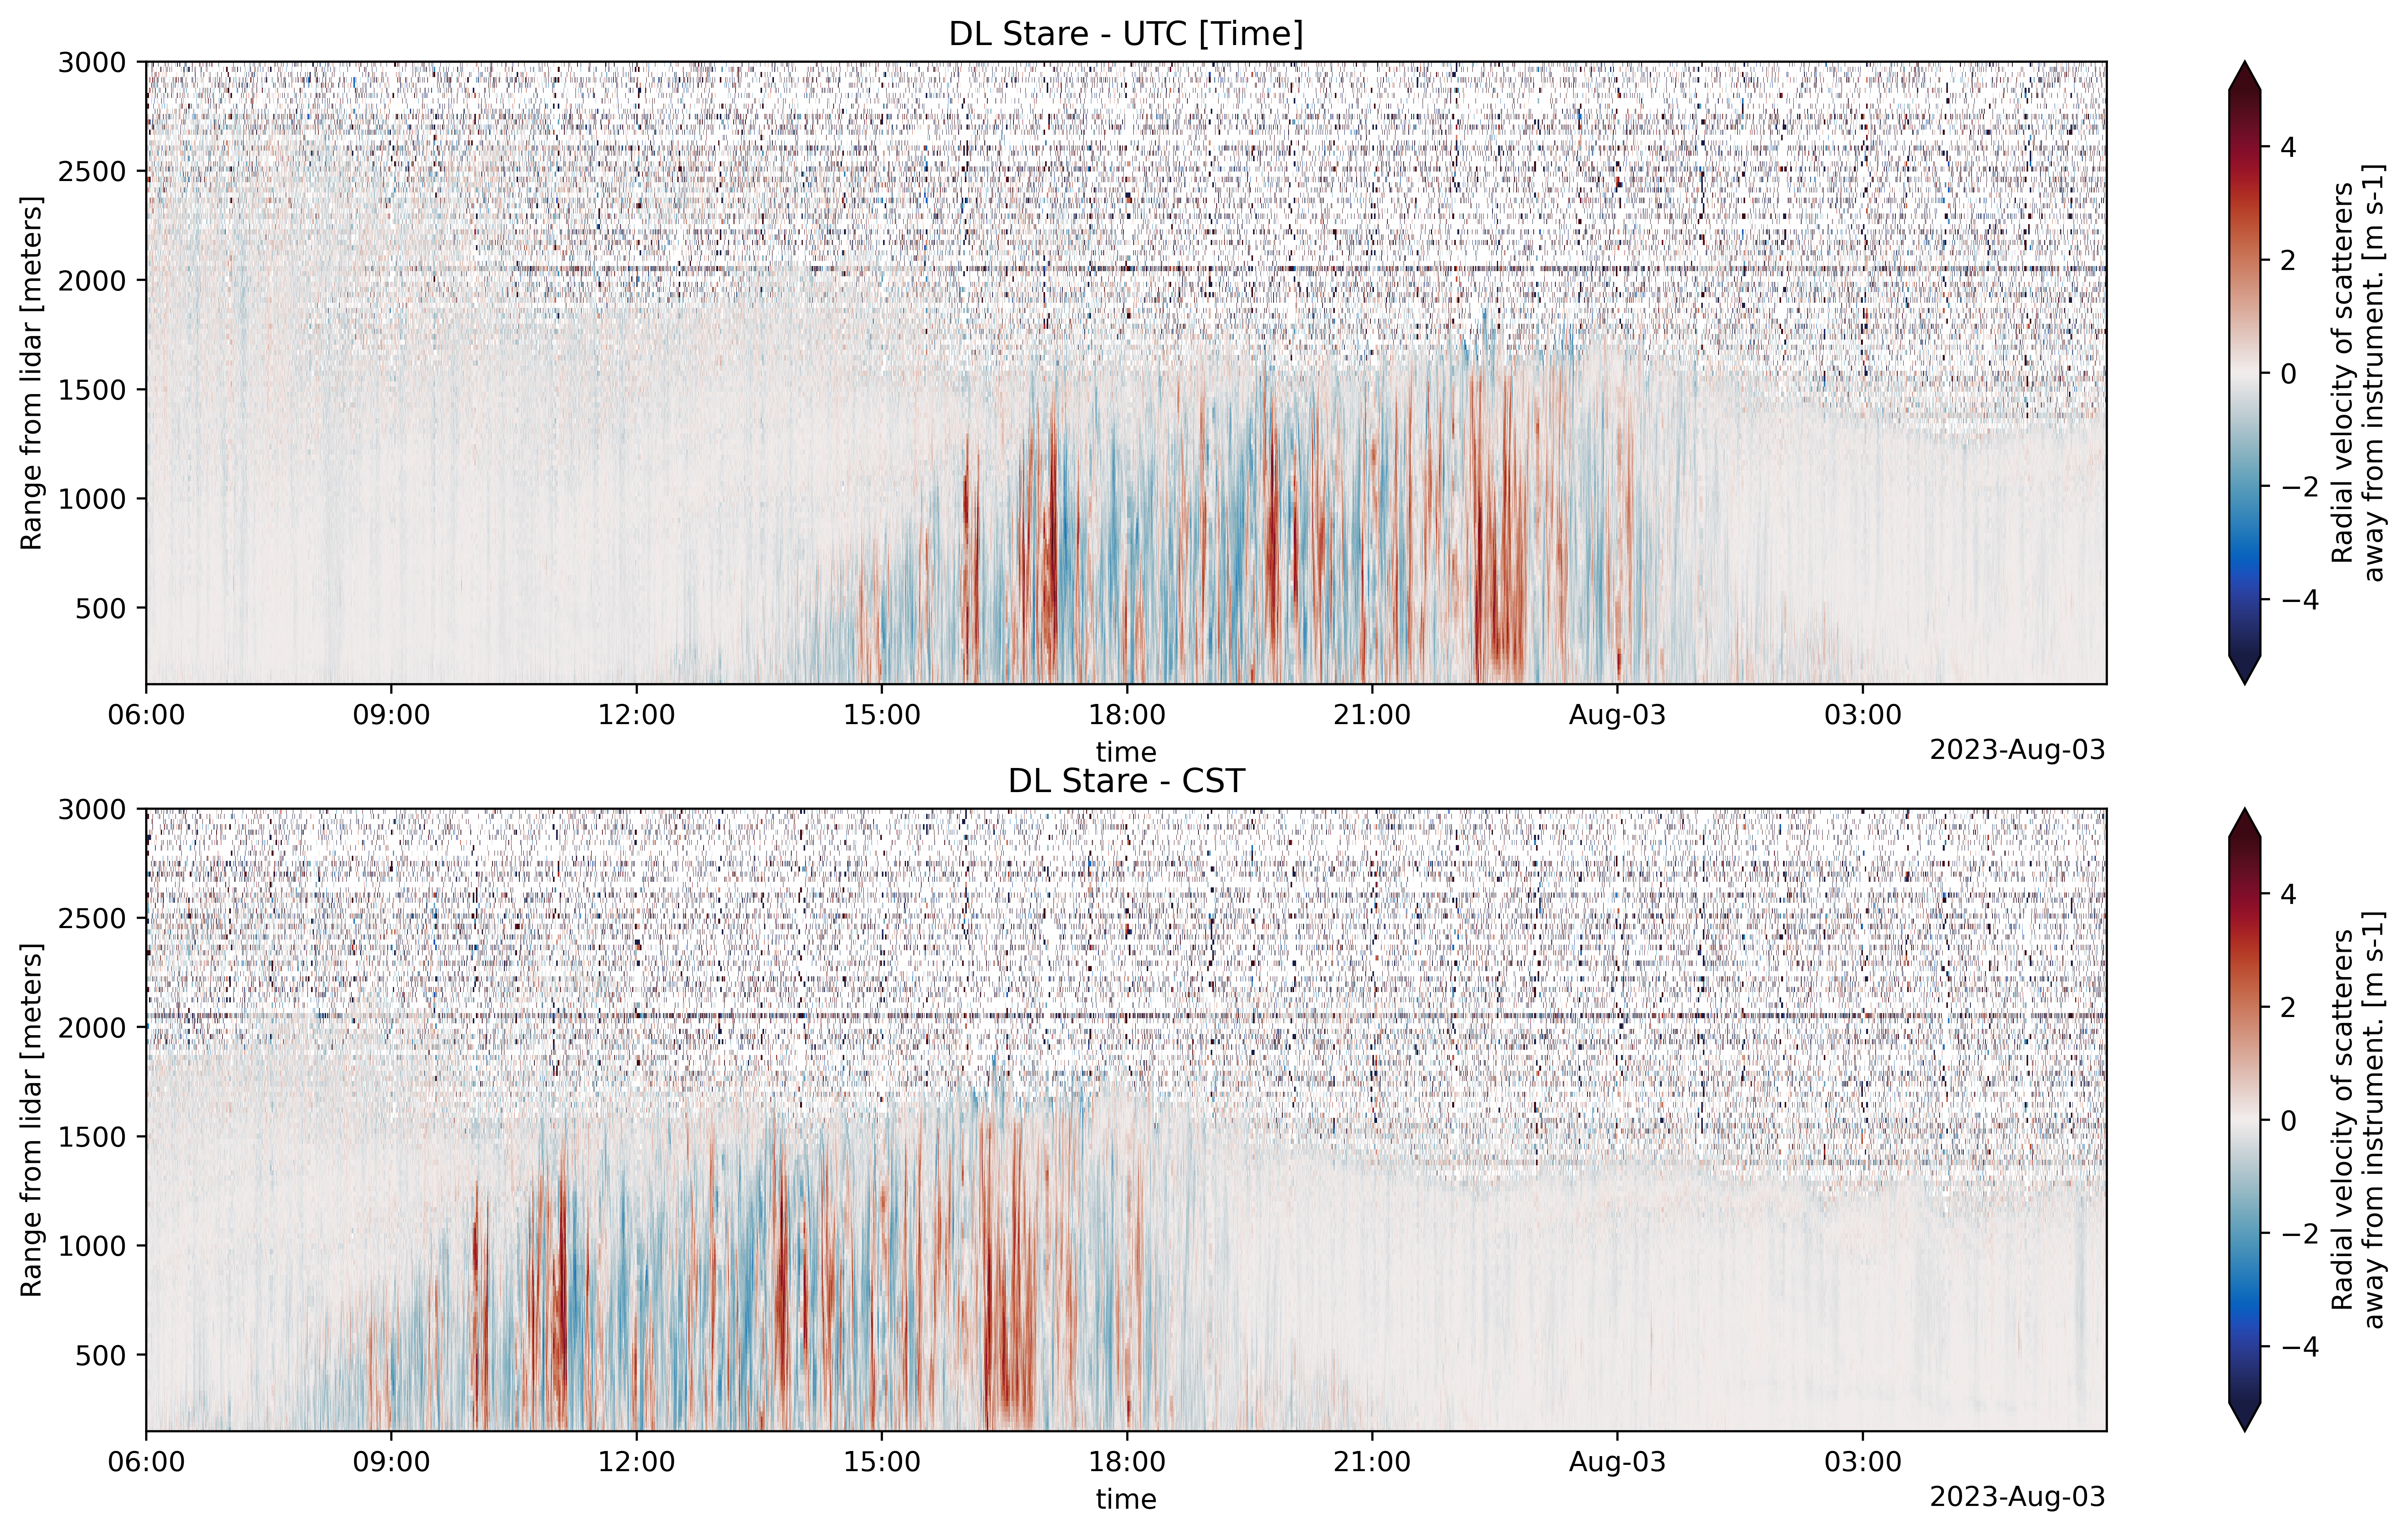

In [8]:
import matplotlib.dates as mdates
from zoneinfo import ZoneInfo

fig, axarr = plt.subplots(2, 1, figsize=(16,9), dpi=500)

# uncorrected
lidar_stare["radial_velocity"].T.where(filt).plot(cmap='balance', 
                                                  vmin=-5, 
                                                  vmax=5,
                                                  ax=axarr[0])
axarr[0].set_ylim([150, 3000])
axarr[0].set_xlim(["2023-08-02T06:00:00", "2023-08-03T05:59:00"])

# corrected
lidar_stare_time_corr["radial_velocity"].T.where(corrected_filt).plot(cmap='balance',
                                                                      vmin=-5, 
                                                                      vmax=5,
                                                                      ax=axarr[1])

axarr[1].set_ylim([150, 3000])
axarr[1].set_xlim(["2023-08-02T06:00:00", "2023-08-03T05:59:00"])

axarr[0].set_title("DL Stare - UTC [Time]")
axarr[1].set_title("DL Stare - CST")

## CL-61 

In [9]:
# uncorrected time files
file_list = ["/home/obrienj/crocus-analysis/ages+/neiu.cl61.20230801_20230728.nc",
             "/home/obrienj/crocus-analysis/ages+/neiu.cl61.20230802_20230729.nc"]

In [10]:
import pandas as pd

# read all the files within the filelist
ds_uncorrected = act.io.read_arm_netcdf(file_list)

variables=['beta_att', 'p_pol', 'x_pol', 'linear_depol_ratio']
#variables=['beta_att', 'p_pol', 'x_pol']
for var in variables:
    if var != 'linear_depol_ratio':
        ds_uncorrected = act.corrections.correct_ceil(ds_uncorrected, var_name=var)

# update the ceilometer datastream name
ds_uncorrected.attrs['datastream'] = 'crocus-NEIU-ceilometer.b1'

ds2 = ds_uncorrected.copy(deep=True)
t_adj   = ds_uncorrected.time.values - pd.Timedelta(hours=16) + pd.Timedelta(days=5)

# write back as tz-naive (xarray requires tz-naive datetime64)
ds2 = ds2.assign_coords(time=t_adj.astype("datetime64[ns]"))
ds2.time.attrs["timezone"] = "UTC"


In [11]:
ds2

<xarray.Dataset> Size: 189MB
Dimensions:                            (time: 2870, layer: 5, range: 3276)
Coordinates:
  * range                              (range) float64 26kB 0.0 ... 1.572e+04
  * layer                              (layer) float64 40B 1.0 2.0 3.0 4.0 5.0
  * time                               (time) datetime64[ns] 23kB 2023-08-01T...
Data variables: (12/20)
    cloud_base_heights                 (time, layer) float64 115kB dask.array<chunksize=(1435, 5), meta=np.ndarray>
    vertical_visibility                (time) float64 23kB dask.array<chunksize=(1435,), meta=np.ndarray>
    p_pol                              (time, range) float32 38MB dask.array<chunksize=(1435, 3276), meta=np.ndarray>
    x_pol                              (time, range) float32 38MB dask.array<chunksize=(1435, 3276), meta=np.ndarray>
    beta_att                           (time, range) float32 38MB dask.array<chunksize=(1435, 3276), meta=np.ndarray>
    linear_depol_ratio                 (time, range) float32 38MB dask.array<chunksize=(1435, 3276), meta=np.ndarray>
    ...                                 ...
    cloud_penetration_depth            (time, layer) float64 115kB dask.array<chunksize=(1435, 5), meta=np.ndarray>
    cloud_thickness                    (time, layer) float64 115kB dask.array<chunksize=(1435, 5), meta=np.ndarray>
    precipitation_detection            (time) float32 11kB dask.array<chunksize=(1435,), meta=np.ndarray>
    fog_detection                      (time) float32 11kB dask.array<chunksize=(1435,), meta=np.ndarray>
    receiver_gain                      (time) float32 11kB dask.array<chunksize=(1435,), meta=np.ndarray>
    overlap_function                   (time, range) float32 38MB dask.array<chunksize=(1435, 3276), meta=np.ndarray>
Attributes: (12/22)
    title:                          CL61D CL61 with Depolarization
    institution:                    NEIU
    source:                         
    conventions:                    CF-1.8
    schema_version:                 1.3
    sw_version:                     1.2.7
    ...                             ...
    Merged in this dimension:       time
    _file_dates:                    ['20230728', '20230728']
    _file_times:                    ['000050', '000050']
    _datastream:                    act_datastream
    _arm_standards_flag:            0
    datastream:                     crocus-NEIU-ceilometer.b1

Text(0.5, 0, 'Time [UTC]')

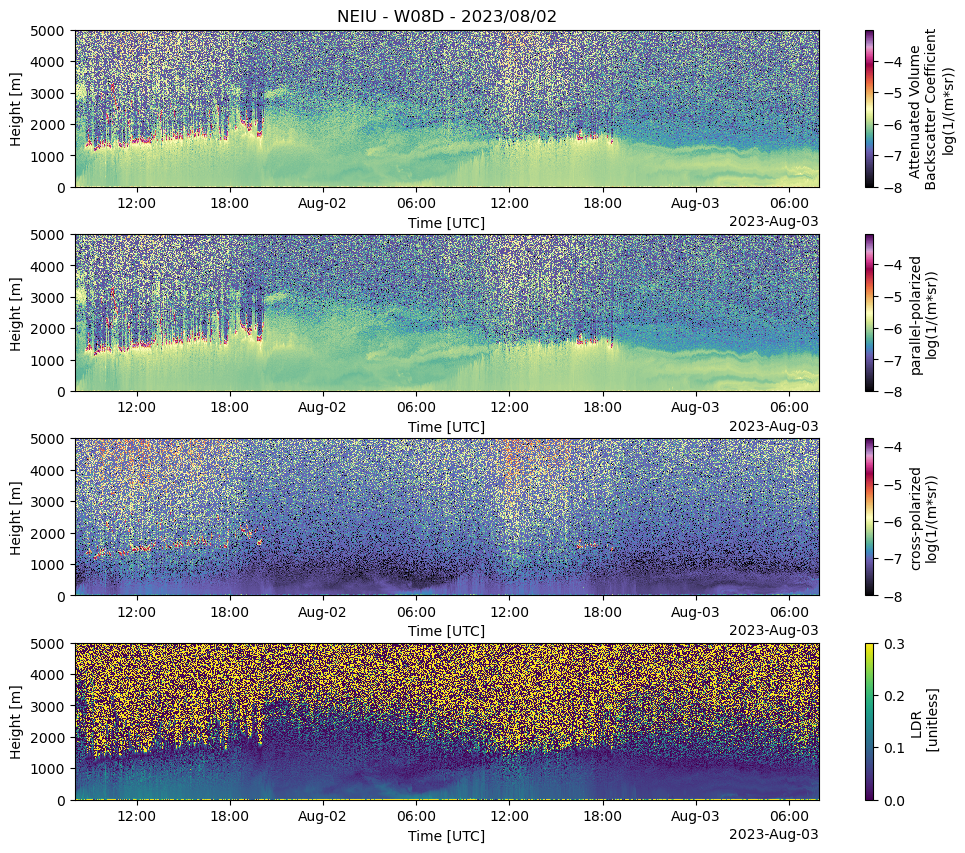

In [12]:
fig, axarr = plt.subplots(4, 1, figsize=[12, 10])
fig.subplots_adjust(hspace=0.3)

axn = 0
newDate = "2023/08/02"
for variable in variables:
    #display = act.plotting.TimeSeriesDisplay(ds, figsize=(8,4))
    if variable == 'linear_depol_ratio':
        cbs = ds2[variable].plot(x='time',
                                vmin=0,
                                vmax=0.3,
                                ax=axarr[axn],
                                add_labels=False,
                                add_colorbar=False
        )
        axarr[axn].set_ylabel("Height [m]")
        axarr[axn].set_xlabel("Time [UTC]")
        axarr[axn].set_ylim([0, 5000])
        cbar = fig.colorbar(cbs)
        cbar.set_label("LDR \n [unitless]")
        axn += 1
    else:
        cbs = ds2[variable].plot(x='time',
                                cmap='ChaseSpectral',
                                vmin=-8,
                                ax=axarr[axn],
                                add_labels=False,
                                add_colorbar=False
        )
        axarr[axn].set_ylabel("Height [m]")
        axarr[axn].set_xlabel("Time [UTC]")
        axarr[axn].set_ylim([0, 5000])
        cbar = fig.colorbar(cbs)
        if ds2[variable].long_name.split(" ")[0] == "attenuated":
            cbar.set_label("Attenuated Volume \n Backscatter Coefficient \n" + ds2[variable].units)
        else:
            cbar.set_label(ds2[variable].long_name.split(" ")[0] + '\n' + ds2[variable].units)
        axn += 1

axarr[0].set_title("NEIU - W08D - " + newDate)
axarr[3].set_xlabel("Time [UTC]")

## Final Figure 

Text(0.5, 0, 'Time (CST)')

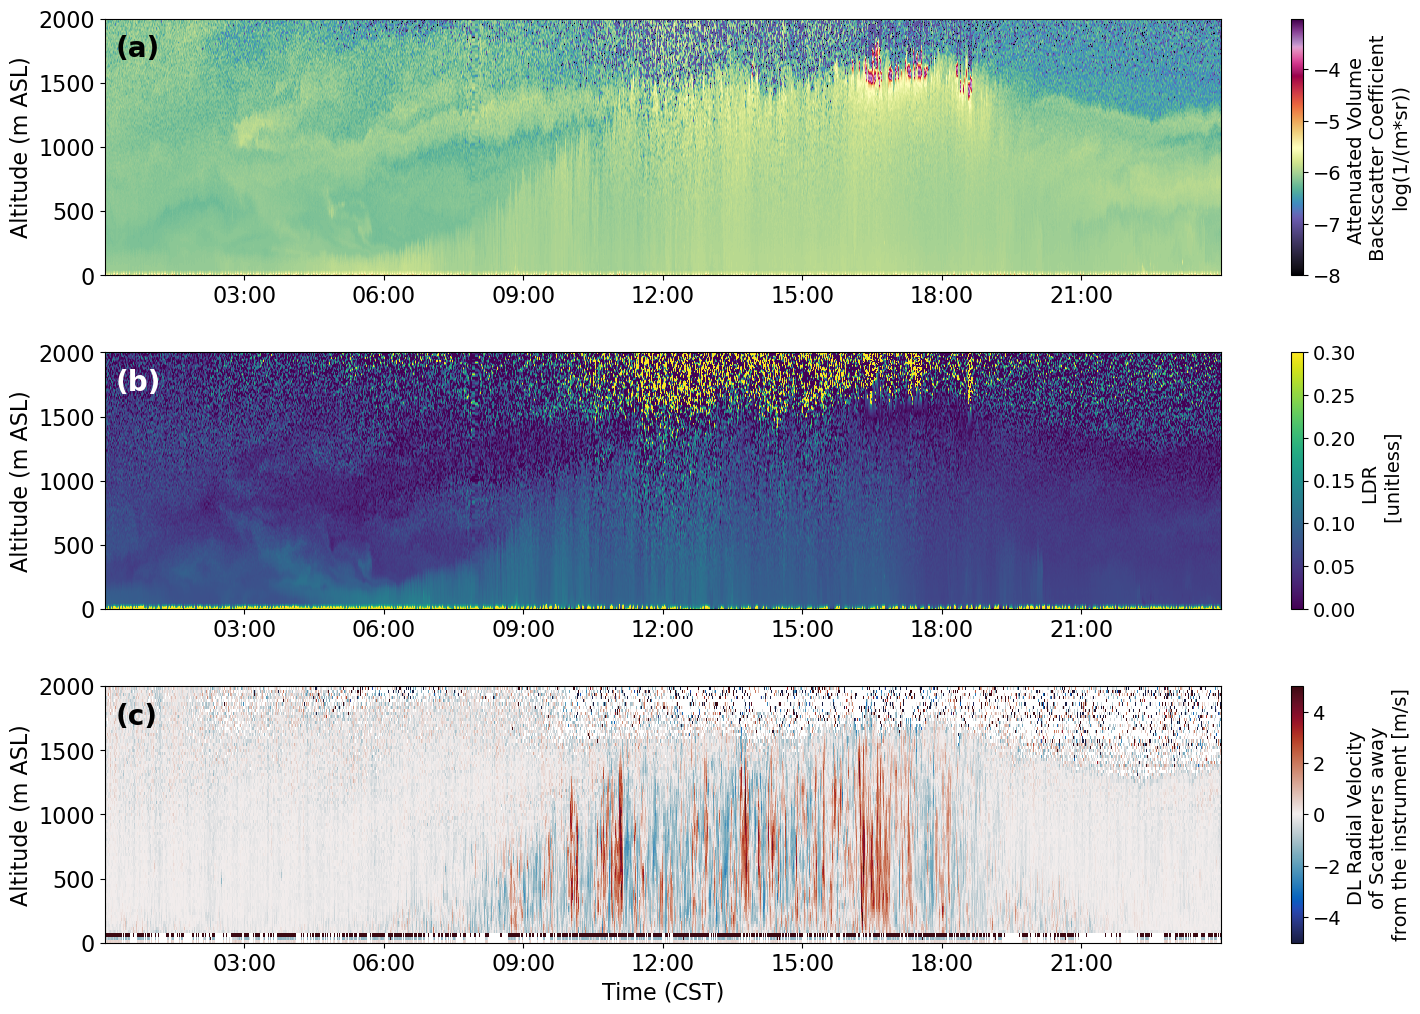

In [13]:
fig, axn = plt.subplots(3, 1, figsize=[18,12])
fig.subplots_adjust(hspace=0.3)

cbs = ds2["beta_att"].plot(x='time',
                          cmap='ChaseSpectral',
                          vmin=-8,
                          ax=axn[0],
                          add_labels=False,
                          add_colorbar=False
)


axn[0].set_ylabel("Altitude (m ASL)", fontsize=16)
axn[0].set_xlabel(" ")
axn[0].set_ylim([0, 2000])
axn[0].set_xlim(["2023-08-02T00:00:00", "2023-08-03T00:00:00"])
axn[0].tick_params(axis="both", labelsize=16)
axn[0].text(0.01, 0.85, "(a)", fontsize=20, transform=axn[0].transAxes, color="black", fontweight="bold")

cbar = fig.colorbar(cbs)
cbar.set_label("Attenuated Volume \n Backscatter Coefficient \n" + ds2["beta_att"].units, fontsize=14)
cbar.ax.tick_params(labelsize=14)

axn[0].xaxis.set_major_locator(mdates.HourLocator(byhour=[3,6,9,12,15,18,21]))
axn[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axn[0].tick_params(axis='x', labelrotation=0)
for lbl in axn[0].get_xticklabels():
    lbl.set_multialignment('center')

cbs = ds2["linear_depol_ratio"].plot(x='time',
                        vmin=0,
                        vmax=0.3,
                        ax=axn[1],
                        add_labels=False,
                        add_colorbar=False
        )
axn[1].set_ylabel("Altitude (m ASL)", fontsize=16)
axn[1].set_xlabel(" ")
axn[1].set_ylim([0, 2000])
axn[1].set_xlim(["2023-08-02T00:00:00", "2023-08-03T00:00:00"])
axn[1].text(0.01, 0.85, "(b)", fontsize=20, color="white", transform=axn[1].transAxes, fontweight="bold")
axn[1].tick_params(axis="both", labelsize=16)
cbar = fig.colorbar(cbs)
cbar.set_label("LDR \n [unitless]", fontsize=14)
cbar.ax.tick_params(labelsize=14)

axn[1].xaxis.set_major_locator(mdates.HourLocator(byhour=[3,6,9,12,15,18,21]))
axn[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axn[1].tick_params(axis='x', labelrotation=0)
for lbl in axn[1].get_xticklabels():
    lbl.set_multialignment('center')

cbs = lidar_stare_time_corr["radial_velocity"].T.where(corrected_filt).plot(cmap='balance',
                                                                            vmin=-5, 
                                                                            vmax=5,
                                                                            ax=axn[2],
                                                                            add_labels=False,
                                                                            add_colorbar=False)

axn[2].set_ylabel("Altitude (m ASL)", fontsize=16)
axn[2].set_ylim([0, 2000])
axn[2].set_xlim(["2023-08-02T00:00:00", "2023-08-03T00:00:00"])
axn[2].text(0.01, 0.85, "(c)", fontsize=20, transform=axn[2].transAxes, fontweight="bold")
axn[2].tick_params(axis="both", labelsize=16)
cbar = fig.colorbar(cbs)
cbar.set_label("DL Radial Velocity \nof Scatterers away \nfrom the instrument [m/s]", fontsize=14)
cbar.ax.tick_params(labelsize=14)

axn[2].xaxis.set_major_locator(mdates.HourLocator(byhour=[3,6,9,12,15,18,21]))
axn[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
axn[2].tick_params(axis='x', labelrotation=0)
for lbl in axn[2].get_xticklabels():
    lbl.set_multialignment('center')

axn[0].set_ylabel("Altitude (m ASL)", fontsize=16)
axn[2].set_xlabel("Time (CST)", fontsize=16)
